### 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


### 2. Load the Dataset

In [3]:
file_path = "NewYorkCityTaxiTripDuration (1).csv"
df = pd.read_csv(file_path)

df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### 3 Sample the Dataset

In [4]:
df_sample = df.sample(n=15000, random_state=42)

df_sample.shape


(15000, 11)

### 4️ – Feature Selection

In [5]:
X = df_sample[['pickup_latitude', 'pickup_longitude']]
X.head()


,pickup_latitude,pickup_longitude
67250,40.735943,-73.985611
1397036,40.764351,-73.978394
1021087,40.744389,-73.989059
951424,40.731136,-73.990326
707882,40.646675,-73.789497


### 5. Data Preprocessing (StandardScaler)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-0.53035781, -0.31996783],
       [ 0.46919342, -0.13464579],
       [-0.2331903 , -0.40851494],
       [-0.69947753, -0.44103445],
       [-3.67128682,  4.71565917]])

### 6. DBSCAN Experiment 1 (eps = 0.2)

In [7]:
dbscan_1 = DBSCAN(eps=0.2, min_samples=5)
labels_1 = dbscan_1.fit_predict(X_scaled)

labels_1[:10]


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

### 7. DBSCAN Experiment 2 (eps = 0.3)

In [8]:
dbscan_2 = DBSCAN(eps=0.3, min_samples=5)
labels_2 = dbscan_2.fit_predict(X_scaled)

labels_2[:10]


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

### 8. DBSCAN Experiment 3 (eps = 0.5)

In [9]:
dbscan_3 = DBSCAN(eps=0.5, min_samples=5)
labels_3 = dbscan_3.fit_predict(X_scaled)

labels_3[:10]


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

### 9. Cluster Evaluation Function

In [10]:
def evaluate_clusters(labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)

    print(name)
    print("Number of clusters (excluding noise):", n_clusters)
    print("Number of noise points:", n_noise)
    print("Noise ratio:", round(noise_ratio, 2))

    if n_clusters > 1:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        print("Silhouette Score:", round(score, 3))
        return score
    else:
        print("Silhouette Score: Not Applicable")
        return None


### 10. Evaluate All Experiments

In [11]:
score_1 = evaluate_clusters(labels_1, "Experiment 1 (eps = 0.2)")
print()

score_2 = evaluate_clusters(labels_2, "Experiment 2 (eps = 0.3)")
print()

score_3 = evaluate_clusters(labels_3, "Experiment 3 (eps = 0.5)")


Experiment 1 (eps = 0.2)
Number of clusters (excluding noise): 12
Number of noise points: 98
Noise ratio: 0.01
Silhouette Score: 0.177

Experiment 2 (eps = 0.3)
Number of clusters (excluding noise): 6
Number of noise points: 51
Noise ratio: 0.0
Silhouette Score: 0.592

Experiment 3 (eps = 0.5)
Number of clusters (excluding noise): 2
Number of noise points: 23
Noise ratio: 0.0
Silhouette Score: 0.805


### 11. Visualization Function

In [13]:
def plot_clusters(labels, title):
    plt.figure(figsize=(8, 6))

    for label in set(labels):
        mask = labels == label
        if label == -1:
            plt.scatter(
                X.iloc[mask, 1],
                X.iloc[mask, 0],
                c='black',
                s=5,
                label='Noise'
            )
        else:
            plt.scatter(
                X.iloc[mask, 1],
                X.iloc[mask, 0],
                s=5,
                label=f'Cluster {label}'
            )

    plt.xlabel("Pickup Longitude")
    plt.ylabel("Pickup Latitude")
    plt.title(title)
    plt.legend(markerscale=2)
    plt.show()


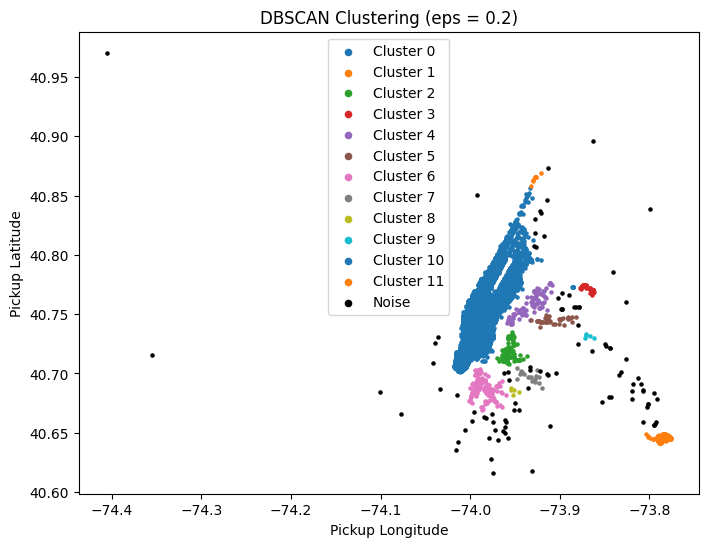

In [14]:
plot_clusters(labels_1, "DBSCAN Clustering (eps = 0.2)")


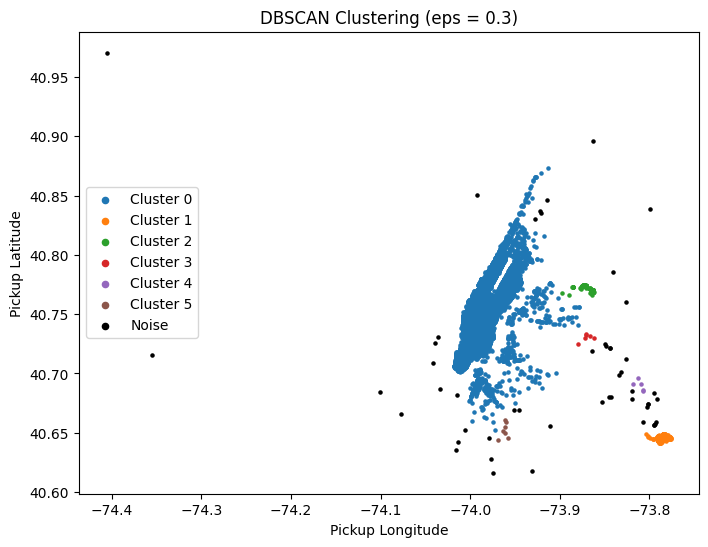

In [15]:
plot_clusters(labels_2, "DBSCAN Clustering (eps = 0.3)")


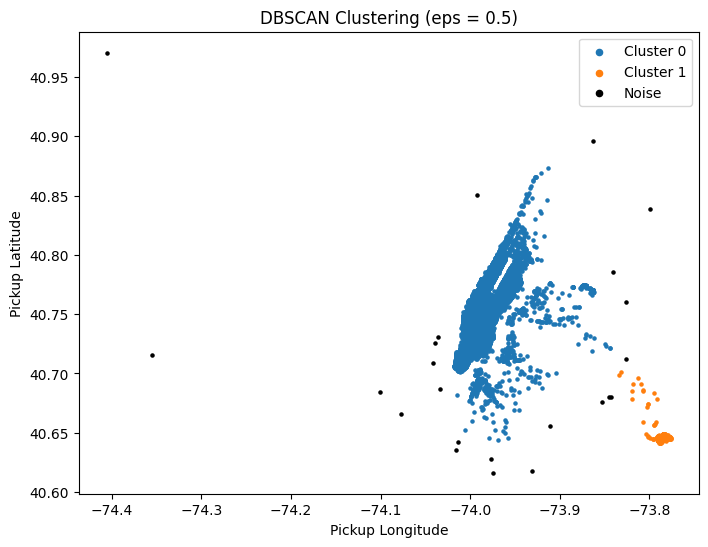

In [16]:
plot_clusters(labels_3, "DBSCAN Clustering (eps = 0.5)")


### Best Model Selection

In [17]:
results = {
    0.2: score_1,
    0.3: score_2,
    0.5: score_3
}

best_eps = max(
    results,
    key=lambda k: results[k] if results[k] is not None else -1
)

print("✅ Best eps value =", best_eps)


✅ Best eps value = 0.5
